# Análise Exploratória de Dados - parte 4

> **Autor**: Miguel Vieira Machado Pim  
> **Contexto**: Desafio do processo seletivo de estágio IndustriALL

Notebooks anteriores a este:

1. [`01_pre_processing`](01_pre_processing.ipynb)
2. [`02_data_visualization`](02_data_visualization.ipynb)

## Bibliotecas

In [1]:
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

## Funções

In [2]:
def preprocess_data(data_path: Path) -> pd.DataFrame:
    """
    Essa função coleta todos os 53 arquivos csv e converte eles em um único dataframe final.

    Args:
        data_path (Path): Caminho para a pasta que contém os arquivos csv.

    Returns:
        pd.DataFrame: Dataframe final contendo todas as features e a coluna target.
    """
    # Coletando todos os arquivos
    feature_dfs = []
    target_df = None

    for file in data_path.glob("*.csv"):
        if "target" in file.name:
            target_df = pd.read_csv(file)
            target_df.columns = ["timestamp", "target"]
        else:
            sensor_id = int(re.search(r"\d+", file.stem).group())
            
            df = pd.read_csv(file)
            df.columns = ["timestamp", f"sensor_{sensor_id}"]

            feature_dfs.append(df)
    
    feature_dfs.sort(
        key=lambda df: int(df.columns[1].split("_")[1])
    )
    
    # Tratando tipos dos datasets
    for df in feature_dfs:
        df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    target_df["target"] = target_df["target"].map({
        "NORMAL": 0,
        "ANORMAL": 1
    }).astype(int)
    target_df["timestamp"] = pd.to_datetime(target_df["timestamp"])
    
    # Construindo dataset final
    df_final = (
        pd.concat(
            [target_df.set_index("timestamp")] +
            [df.set_index("timestamp") for df in feature_dfs],
            axis=1,
            join="outer" # Para mantermos timestamps que não estão em todas as tabelas
        )
        .sort_index()
    )
    
    return df_final

In [3]:
def calcular_fft(
    serie,
    dt_minutes=1,
    remover_media=True,
    normalizar=False
):
    x = serie.astype(float).values.copy()

    if remover_media:
        x = x - x.mean()

    if normalizar:
        std = x.std()
        if std != 0:
            x = x / std

    n = len(x)

    fft_vals = np.fft.rfft(x)
    fft_freqs = np.fft.rfftfreq(n, d=dt_minutes * 60)  # Hz (ciclos por segundo)

    amplitude = np.abs(fft_vals) / n

    # removendo componente DC (frequência zero)
    fft_freqs = fft_freqs[1:]
    amplitude = amplitude[1:]

    # convertendo para ciclos por hora
    freq_cph = fft_freqs * 3600

    return freq_cph, amplitude


def plot_fft_sensores(
    df,
    sensores=None,
    modo="separado",   # "separado" ou "juntos"
    dt_minutes=1,
    remover_media=True,
    normalizar=False,
    max_freq_cph=None,
    figsize=(16, 20),
    ncols=3
):
    if sensores is None:
        sensores = sorted(
            [col for col in df.columns if col.startswith("sensor_")],
            key=lambda x: int(x.split("_")[1])
        )

    if modo == "juntos":
        fig, ax = plt.subplots(figsize=(12, 6))

        for sensor in sensores:
            freq_cph, amplitude = calcular_fft(
                df[sensor],
                dt_minutes=dt_minutes,
                remover_media=remover_media,
                normalizar=normalizar
            )

            if max_freq_cph is not None:
                mask = freq_cph <= max_freq_cph
                freq_cph = freq_cph[mask]
                amplitude = amplitude[mask]

            ax.plot(freq_cph, amplitude, label=sensor, alpha=0.8)

        ax.set_title("Espectro FFT dos sensores")
        ax.set_xlabel("Frequência (ciclos por hora)")
        ax.set_ylabel("Amplitude")
        ax.grid(True, alpha=0.3)
        ax.legend(ncol=2, fontsize=8)
        plt.tight_layout()
        plt.show()

    elif modo == "separado":
        n = len(sensores)
        nrows = math.ceil(n / ncols)

        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=figsize,
            squeeze=False
        )

        axes = axes.flatten()

        for i, sensor in enumerate(sensores):
            freq_cph, amplitude = calcular_fft(
                df[sensor],
                dt_minutes=dt_minutes,
                remover_media=remover_media,
                normalizar=normalizar
            )

            if max_freq_cph is not None:
                mask = freq_cph <= max_freq_cph
                freq_cph = freq_cph[mask]
                amplitude = amplitude[mask]

            axes[i].plot(freq_cph, amplitude)
            axes[i].set_title(sensor)
            axes[i].set_xlabel("Freq. (ciclos/hora)")
            axes[i].set_ylabel("Amplitude")
            axes[i].grid(True, alpha=0.3)

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle("Espectro FFT dos sensores", y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()

In [4]:
def plotar_distribuicao_temporal_falhas(
    df,
    target_col="target",
    figsize=(18, 5)
):
    dados = df.copy()

    # Garante que o timestamp esteja no índice
    if not isinstance(dados.index, pd.DatetimeIndex):
        dados["timestamp"] = pd.to_datetime(dados["timestamp"])
        dados = dados.set_index("timestamp")

    dados = dados.sort_index()

    # Compatível com target numérico ou textual
    falha = dados[target_col].isin([1, "ANORMAL"])

    # Seleciona somente o início de cada evento de falha
    inicio_falha = falha & ~falha.shift(fill_value=False)
    eventos = dados.loc[inicio_falha].copy()

    # Ordem iniciando na quinta-feira
    ordem_dias_num = [3, 4, 5, 6, 0, 1, 2]
    nomes_dias = {
        0: "Segunda",
        1: "Terça",
        2: "Quarta",
        3: "Quinta",
        4: "Sexta",
        5: "Sábado",
        6: "Domingo"
    }

    falhas_dia = (
        eventos.index.dayofweek
        .value_counts()
        .reindex(ordem_dias_num, fill_value=0)
        .rename(index=nomes_dias)
    )

    falhas_hora = (
        eventos.index.hour
        .value_counts()
        .reindex(range(24), fill_value=0)
    )

    falhas_mes = (
        eventos
        .groupby(eventos.index.to_period("M"))
        .size()
    )

    falhas_mes.index = falhas_mes.index.strftime("%b/%Y")

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    sns.barplot(
        x=falhas_dia.index,
        y=falhas_dia.values,
        ax=axes[0]
    )
    axes[0].set_title("Inícios de falha por dia da semana")
    axes[0].set_xlabel("Dia da semana")
    axes[0].set_ylabel("Quantidade de falhas")
    axes[0].tick_params(axis="x", rotation=45)

    sns.barplot(
        x=falhas_hora.index,
        y=falhas_hora.values,
        ax=axes[1]
    )
    axes[1].set_title("Inícios de falha por hora do dia")
    axes[1].set_xlabel("Hora")
    axes[1].set_ylabel("Quantidade de falhas")

    sns.barplot(
        x=falhas_mes.index,
        y=falhas_mes.values,
        ax=axes[2]
    )
    axes[2].set_title("Inícios de falha por mês")
    axes[2].set_xlabel("Mês")
    axes[2].set_ylabel("Quantidade de falhas")
    axes[2].tick_params(axis="x", rotation=45)

    for ax in axes:
        for container in ax.containers:
            ax.bar_label(container, padding=0.8)

    fig.suptitle(
        f"Distribuição temporal dos eventos de falha — {len(eventos)} eventos",
        fontsize=15,
        y=1.03
    )

    plt.tight_layout()
    plt.show()

    return eventos

## Carregando os dados

In [5]:
data_path = Path("../data")

industry_df = preprocess_data(data_path)

In [6]:
eda_df = industry_df.copy()
eda_df

,target,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,0,4.548754,90.886874,58.698896,89.301134,1011.733181,97.284889,33.248746,-10.390227,29.262578,...,101.547023,154.291476,114.466107,103.082616,119.246973,60.729332,310.022461,124.735196,426.651658,410.820484
2018-04-01 00:01:00,0,7.887998,56.555373,80.802810,120.898222,1358.466600,202.583688,32.494870,19.427739,61.038519,...,71.846296,59.239207,90.076161,93.760055,63.457947,62.910653,306.084796,158.822485,375.316113,143.620728
2018-04-01 00:02:00,0,4.975919,182.086958,87.273632,9.914782,1056.489015,147.098428,36.402837,38.900027,30.304666,...,59.174616,87.136301,99.274584,111.916792,60.560834,81.332910,353.863854,88.772027,444.809188,618.898000
2018-04-01 00:03:00,0,6.304142,58.417235,75.059520,64.167463,1619.924847,307.722320,34.283344,46.602862,44.859311,...,0.674927,110.321579,103.978381,103.705604,24.141894,36.219671,301.563110,53.387484,414.052496,427.323378
2018-04-01 00:04:00,0,1.671733,108.946809,94.910470,14.551922,591.648283,-7.684779,30.980682,39.293311,1.229287,...,71.785623,112.435498,103.170425,110.566095,53.913605,116.770552,298.957820,168.746952,431.548430,514.659884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 23:55:00,0,6.066461,128.157145,144.452803,66.621842,1791.181163,172.833101,13.116142,52.438915,32.694638,...,77.001917,105.953758,169.203415,74.959180,159.206995,98.736928,432.326663,199.902569,NaN,343.198701
2018-08-31 23:56:00,0,4.057784,-31.186502,49.775117,69.397205,1166.424000,146.161645,26.785100,17.436183,39.612008,...,32.268873,12.201309,59.127149,149.304241,26.936970,125.800942,402.294815,218.904951,NaN,381.082811
2018-08-31 23:57:00,0,6.751912,80.433446,107.038506,137.923928,1060.918628,106.901675,37.495990,20.406074,33.073722,...,87.497962,90.664739,144.615688,29.140853,118.974814,75.747273,269.339456,260.899365,NaN,452.482461


## Analisando período de falhas

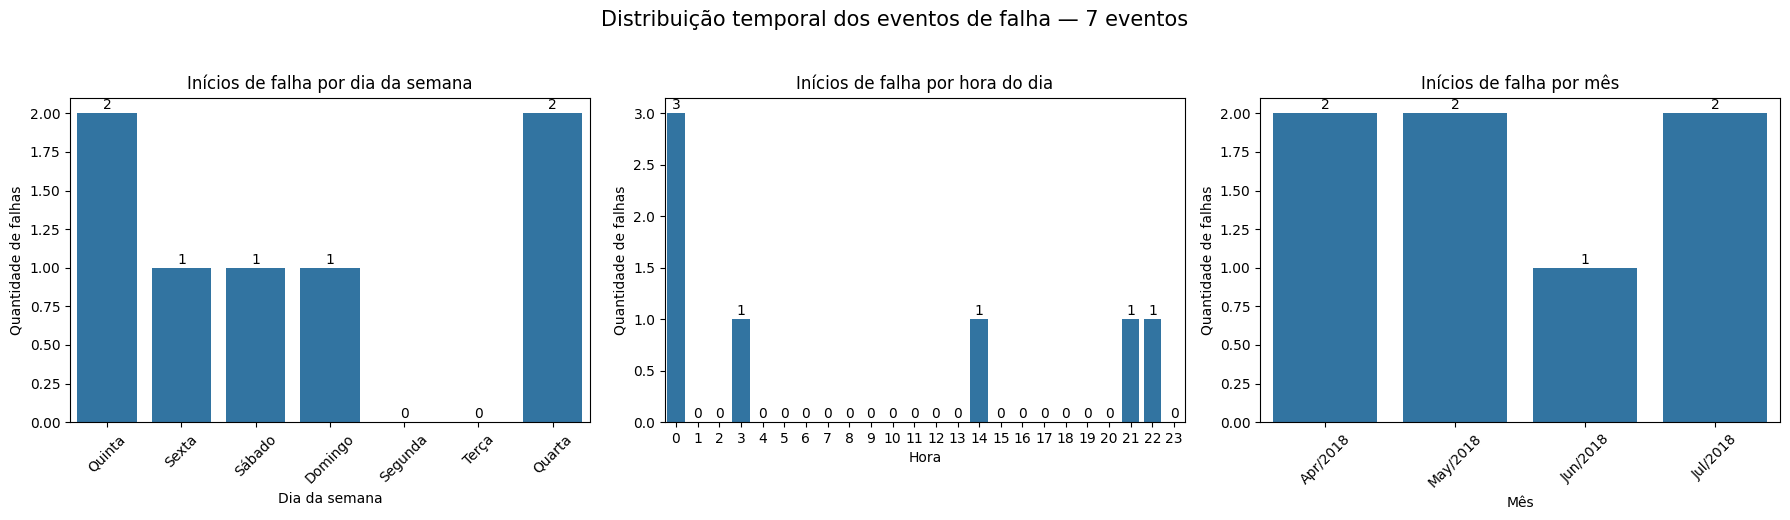

In [7]:
eventos_falha = plotar_distribuicao_temporal_falhas(eda_df)

As falhas parecem ter relação com o dia da semana e com as horas do dia. Nenhuma falha começou na segunda e terça, e 4 das 7 falhas começaram ou na quarta ou quinta. A maioria das falhas também começaram no período da noite/madrugada, apenas uma delas no período da tarde. Portanto a hora do dia também é uma boa feature adicional para o nosso modelo.

Em contrapartida, os meses não parecem influenciar tanto, uma vez que as falhas estão bem distribuidas.

## Analisando transformadas de Fourier

In [8]:
# plot_fft_sensores(
#     eda_df,
#     sensores=None,
#     modo="separado",
#     max_freq_cph=2,
#     figsize=(18, 28),
#     ncols=3
# )